In [1]:
print("hi there ")

hi there 


In [5]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 

In [7]:
from sklearn.datasets import make_moons 
X , y= make_moons(n_samples = 1000 , noise = 0.2 , random_state = 42)


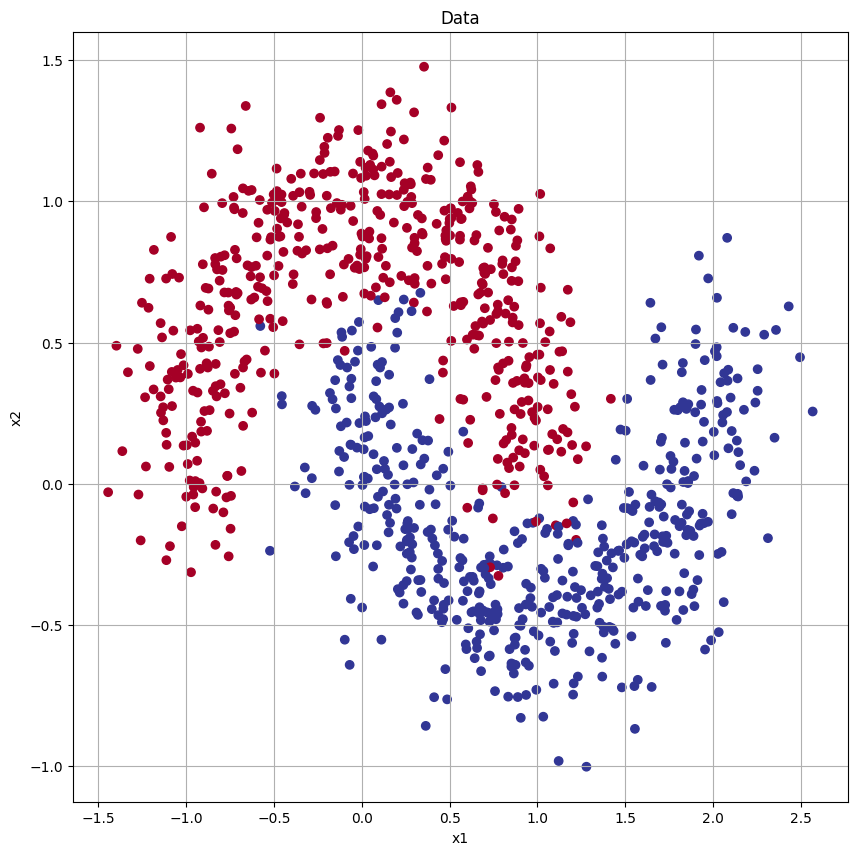

In [13]:
plt.figure(figsize = (10 , 10))
plt.scatter(x = X[: , 0] , y = X[:, 1] , c= y, cmap = plt.cm.RdYlBu)
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.title('Data')
plt.show()


In [14]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [15]:
model = Sequential()

model.add(Dense(10  , input_dim = 2 , activation = 'relu'))
model.add(Dense(1 , activation = 'sigmoid'))

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Set parameters to 0
model.get_weights()

[array([[-0.46814257, -0.56238663,  0.34316605, -0.23546836, -0.3944043 ,
         -0.6095029 , -0.12425917, -0.3542001 , -0.6752043 , -0.36658487],
        [ 0.3870048 , -0.23133224,  0.44252235, -0.08909273, -0.42930308,
         -0.17326754, -0.0209738 ,  0.31310922, -0.34255442, -0.60418403]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.22642916],
        [-0.6812583 ],
        [ 0.61345106],
        [-0.33841914],
        [-0.371675  ],
        [-0.27912626],
        [-0.6963161 ],
        [ 0.54612404],
        [-0.22012061],
        [-0.707349  ]], dtype=float32),
 array([0.], dtype=float32)]

saved the initial weights 

In [17]:
initial_weights = model.get_weights()

In [18]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5310 - loss: 0.6788 - val_accuracy: 0.5950 - val_loss: 0.6548
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5568 - loss: 0.6566 - val_accuracy: 0.6000 - val_loss: 0.6394
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5665 - loss: 0.6511 - val_accuracy: 0.6250 - val_loss: 0.6252
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5897 - loss: 0.6310 - val_accuracy: 0.6300 - val_loss: 0.6124
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6348 - loss: 0.6103 - val_accuracy: 0.6450 - val_loss: 0.6003
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6383 - loss: 0.6049 - val_accuracy: 0.6850 - val_loss: 0.5893
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6499 - loss: 0.5942 - val_accuracy: 0.6900 - val_loss: 0.5786
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6859 - loss: 0.5807 - val_accuracy: 0.6950 - 

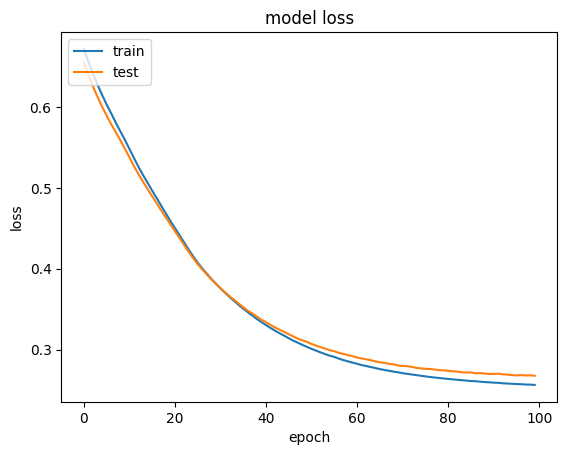

In [19]:
history = model.fit(X ,y  , epochs = 100 , batch_size = 50 , validation_split = 0.2 , verbose = 1)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()



9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

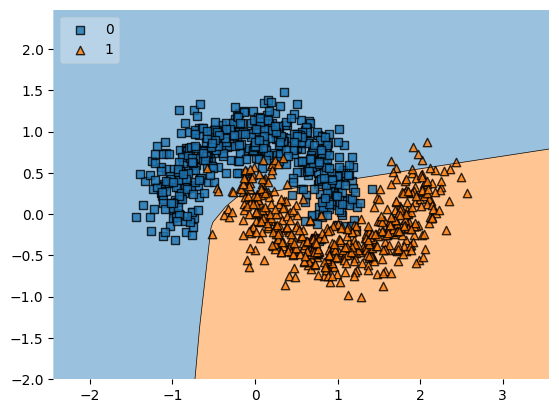

In [20]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

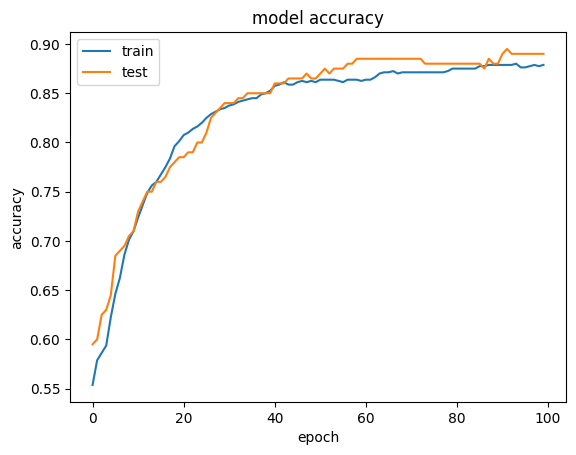

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


## second iteration of the weights initilaization


In [23]:
model2 = Sequential()

model2.add(Dense(2,activation='sigmoid',input_dim=2))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Set parameters to 0
model.get_weights()

[array([[ 0.11569005, -0.92094713,  0.86821544,  0.14889066, -0.90263915,
         -0.9763485 ,  0.12420939, -0.10865171, -1.135706  , -0.8235425 ],
        [ 1.2875799 ,  0.17666481, -0.42845735,  0.95706934,  0.13559006,
          0.28167424,  0.8139208 ,  0.12292661,  0.11319961, -0.3703776 ]],
       dtype=float32),
 array([ 0.28498927, -0.22889929,  0.8622154 ,  0.16534719, -0.22638568,
        -0.27056116,  0.14655064, -0.19550508, -0.26092198, -0.25883588],
       dtype=float32),
 array([[-0.98401487],
        [-1.1837178 ],
        [ 1.3957392 ],
        [-1.3575584 ],
        [-1.0929962 ],
        [-0.76309115],
        [-1.653913  ],
        [ 0.4216711 ],
        [-0.74819976],
        [-1.5022036 ]], dtype=float32),
 array([0.6383792], dtype=float32)]

In [25]:
initial_weights = model.get_weights()

In [26]:
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [27]:
model.set_weights(initial_weights)

In [28]:
model.get_weights()

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [29]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5081 - loss: 2.2867 - val_accuracy: 0.4950 - val_loss: 2.1783
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5204 - loss: 2.0939 - val_accuracy: 0.4950 - val_loss: 2.0576
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5202 - loss: 1.9947 - val_accuracy: 0.4950 - val_loss: 1.9434
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4877 - loss: 2.0402 - val_accuracy: 0.4950 - val_loss: 1.8351
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5054 - loss: 1.8373 - val_accuracy: 0.4950 - val_loss: 1.7344
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5073 - loss: 1.7101 - val_accuracy: 0.4950 - val_loss: 1.6395
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4952 - loss: 1.6956 - val_accuracy: 0.4950 - val_loss: 1.5492
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5232 - loss: 1.4519 - val_accuracy: 0.4950 - 

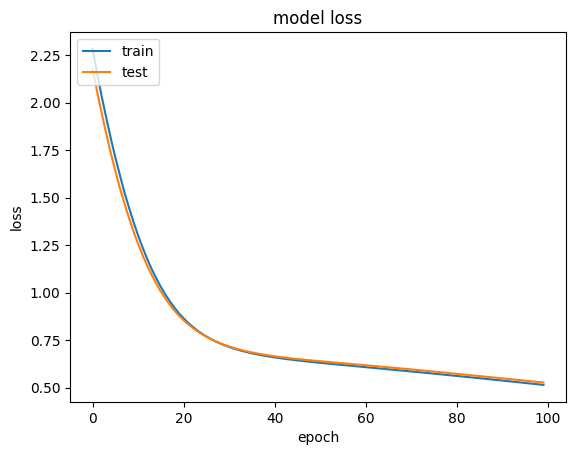

In [30]:
history = model.fit(X , y , epochs = 100 , verbose = 1 , batch_size = 50 , validation_split = 0.2 )


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

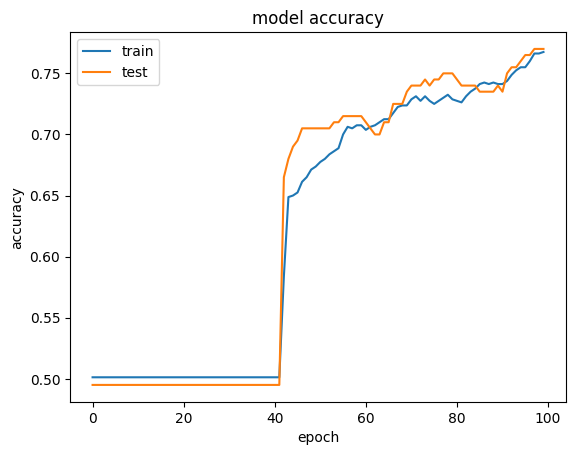

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

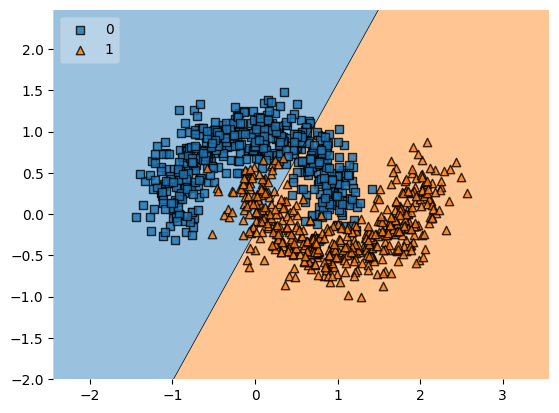

In [32]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)